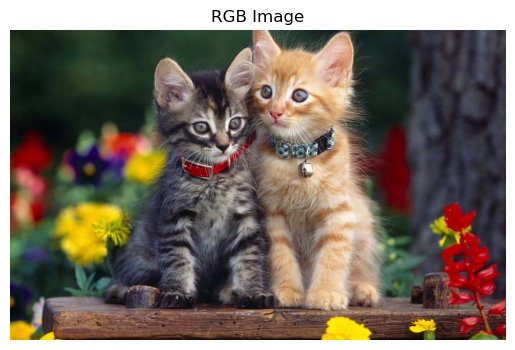

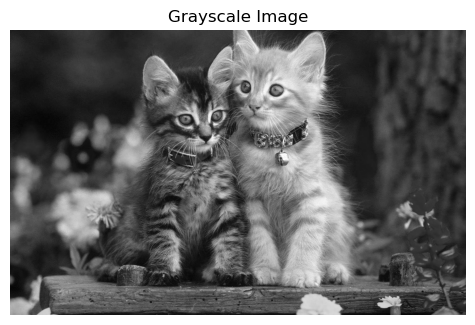

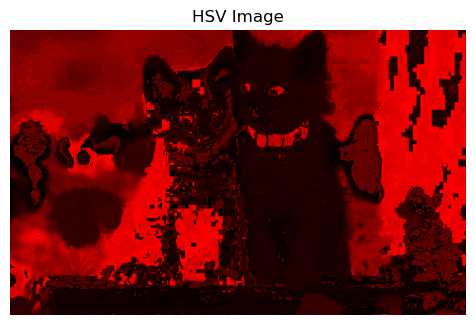

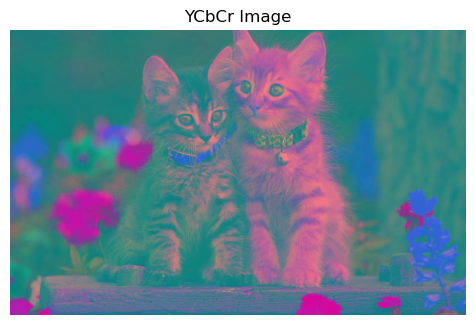

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\Student\Desktop\1012411204_DAA\beautiful-cats-y4upwj5zz45novpx.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("RGB Image")
plt.axis("off")
plt.show()

R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

gray = (0.299 * R + 0.587 * G + 0.114 * B)
plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()


R1 = R/255
G1 = G/255
B1 = B/255
C_max = np.max([R1, G1, B1], axis=0)
C_min = np.min([R1, G1, B1], axis=0)
C_Delta = C_max - C_min

h = np.zeros_like(C_max)
s = np.zeros_like(C_max)
v = C_max 

m = (C_max == R1) & (C_Delta != 0)
h[m] = (60 * ((G1[m] - B1[m]) / C_Delta[m])) % 360
m = (C_max == G1) & (C_Delta != 0)
h[m] = (60 * ((B1[m] - R1[m]) / C_Delta[m] + 2))
m = (C_max == B1) & (C_Delta != 0)
h[m] = (60 * ((R1[m] - G1[m]) / C_Delta[m] + 4))


m = C_max != 0
s[m] = C_Delta[m] / C_max[m]

v = C_max
plt.figure(figsize=(20, 10))
hsv_image = np.stack([h, s, v], axis=-1)
hsv_image = hsv_image.astype(np.uint8)
plt.subplot(1, 3, 2)
plt.imshow(hsv_image)
plt.title("HSV Image")
plt.axis("off")
plt.show()

Y = 0.299 * R + 0.587 * G + 0.114 * B
Cb = 128 - 0.168736 * R - 0.331264 * G + 0.5 * B
Cr = 128 + 0.5 * R - 0.418688 * G - 0.081312 * B

plt.figure(figsize=(20, 10))
YCbCr_image = np.stack([Y, Cb, Cr], axis=-1)
YCbCr_image = np.clip(YCbCr_image, 0, 255).astype(np.uint8)
plt.subplot(1, 3, 3)
plt.imshow(YCbCr_image)
plt.title("YCbCr Image")
plt.axis("off")
plt.show()